importing datasets

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import math
import sklearn 

In [8]:
import pickle
from joblib import load as joblib_load

train_df = pd.read_csv(
	r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\train_df.csv")
val_df = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\val_df.csv")
test_df = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\test_df.csv")
X_train_pca = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\X_train_pca.csv")
pca_path = r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\pca_model.pkl"

try:
    with open(pca_path, "rb") as f:
        pca_model = pickle.load(f)
except Exception:
    pca_model = joblib_load(pca_path)

## We start with the baseline models

In [9]:
X_train = train_df.drop(columns=["defaulted_flag"]).copy()
y_train = train_df["defaulted_flag"].copy()
X_val = val_df.drop(columns=["defaulted_flag"]).copy()
y_val = val_df["defaulted_flag"].copy()
X_test = test_df.drop(columns=["defaulted_flag"]).copy()
y_test = test_df["defaulted_flag"]

#### Dummy Classifier

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create dummy classifier
dummy = DummyClassifier(strategy="most_frequent")

# Fit
dummy.fit(X_train, y_train)

# Predictions
y_pred = dummy.predict(X_val)

# Probabilities
y_prob = dummy.predict_proba(X_val)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, zero_division=0))
print("Recall   :", recall_score(y_val, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_val, y_pred, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_val, y_prob))

Accuracy : 0.91042
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5


In [11]:
print(y_train.mean(),
    y_val.mean(),
    y_test.mean())

0.03176 0.08958 0.021153333333333333


#### Logistic Regression

#first of all we check the assumptions
1. The target vars are already known to be cateogerical to be precise binary here
2. The obsns are mostly independently collected through data and rest of the dependents have been already dropped.
3. checking no perfect multicoolinearity
4. lineatr relo btwn predictors and log odds
5. no extreme outliers
6. sufficient sample size


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# checking multicolinearity
correlation = X_train.corr().abs()

high_corr = (
    correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
)
high_corr.stack().sort_values(ascending=False).head(20)

vif_values = []
# prepare dataframe for VIF calculation
x_vif = X_train.select_dtypes(include=[np.number]).copy()
# drop any constant columns (zero variance) which break VIF computation
zero_var = x_vif.columns[x_vif.std() == 0]
if len(zero_var) > 0:
    x_vif = x_vif.drop(columns=zero_var)

for i in range(x_vif.shape[1]):
    try:
        vif_values.append(variance_inflation_factor(x_vif.values, i))
    except Exception:
        vif_values.append(np.inf)

vif_df = pd.DataFrame({
    "Feature": x_vif.columns,
    "VIF": vif_values
})
vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df
vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df


NameError: name 'x_vif' is not defined

c:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


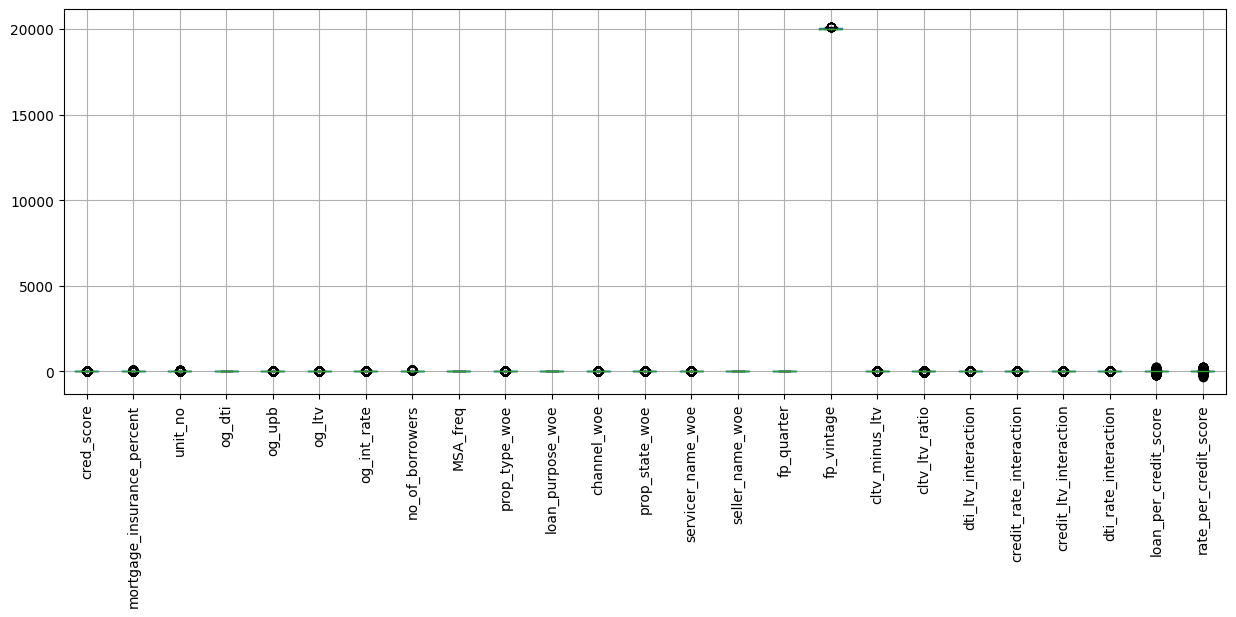

In [ ]:
import matplotlib.pyplot as plt

X_train.boxplot(figsize=(15, 5))
plt.xticks(rotation=90)
plt.show()

therefore we do not observe and multicoolinearity except for the dates and no outliers detected

#### Linear Discriminant Analysis

though a few assumptions we checked werent fullfilled earlier such as normality of features